In [1]:
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = False

# Posterior Eigenmodes: Theory

This notebook gives the theoretical backbone of `posterior-eigenmodes`.

The goal is not to run the package on a specific dataset, but to explain as clearly as possible what the package is measuring geometrically when it compares two posterior distributions defined on the same physical parameter space.

We organize the discussion in three steps:

1. the scientific problem,
2. the one-dimensional case,
3. the comparison of two multidimensional posteriors.

The motivating use case is the one discussed throughout the project: compare a reference posterior `A` against an alternative posterior `B`, and understand not only whether constraints become broader or tighter, but also whether the principal degeneracy directions are preserved or rotated.


## 1. The Problem

Suppose we have two posterior distributions for the same model and the same physical parameters:

- `A`: a reference posterior,
- `B`: an alternative posterior.

In the IDE case study, for example, these may correspond to:

- `A =` full Planck + BAO + SN,
- `B =` compressed CMB geometry + BAO + SN.

The scientific question is not only whether one posterior is globally broader than the other. We want to answer more specific geometric questions:

- Which parameter combinations are well constrained in each case?
- Which combinations become broader or tighter when we move from `A` to `B`?
- Are the main degeneracy directions preserved, or do they rotate?
- Can we construct a basis in which the difference between the two posteriors is easiest to read?

In one dimension this is almost trivial: one posterior is simply narrower, broader, or shifted relative to the other. In `n` dimensions the problem is richer, because a posterior is no longer just a width. Its covariance ellipsoid has:

- axis lengths,
- axis orientations,
- possible shifts of the mean,
- and non-trivial degeneracy directions.

This is why the multidimensional comparison naturally separates into complementary questions:

- how do we describe the geometry of each posterior separately?
- how do we quantify rotations between them?
- how do we quantify direction-dependent changes in variance?


## 2. The Easy Limit: Comparing Two 1D Posteriors

Before going to many dimensions, it is useful to isolate the simplest case.

For a one-dimensional Gaussian posterior with variance $\sigma^2$, the covariance matrix reduces to a single number. Its interpretation is immediate:

- a larger variance means a weaker constraint,
- a smaller variance means a stronger constraint.

If we compare two 1D posteriors, `A` and `B`, the natural quantity is the variance ratio

$\rho = \frac{\sigma_B^2}{\sigma_A^2}.$

This already contains the essential logic of the multidimensional comparison:

- $\rho > 1$: `B` is broader than `A`,
- $\rho < 1$: `B` is tighter than `A`,
- $\rho = 1$: the width is unchanged.

Equivalently, one can work with the standard-deviation ratio $\sqrt{\rho}$.

The multidimensional problem keeps exactly the same idea, but replaces a single axis with many possible directions in parameter space. The central challenge is that in more than one dimension there is no unique notion of “the width” of a posterior until a direction is specified.


## 3. Comparing Two Multidimensional Posteriors

In more than one dimension the second moments of a posterior are described by a covariance matrix. Geometrically, that covariance defines an ellipsoid in parameter space.

The comparison between two posteriors therefore has two layers:

- the internal geometry of `A` and `B` separately,
- the geometry of the change from `A` to `B`.

The discussion below follows this logic through a sequence of concrete questions.


### 3.1 Why do we need more than the 1D intuition?

In `n` dimensions a posterior is not characterized by one number but by a covariance matrix `C`. Its diagonal entries give variances of the original parameters, while the off-diagonal entries encode correlations and degeneracy structure.

The eigen-decomposition

$
C = W \Lambda W^T
$

answers the first geometric question for a single posterior:

- the eigenvectors in `W` define the principal axes of the ellipsoid,
- the eigenvalues in `Λ` give the variances along those axes.

So for a single posterior:

- the axis directions come from the eigenvectors,
- the axis lengths come from the square roots of the eigenvalues.

This is the natural multidimensional generalization of the 1D width.


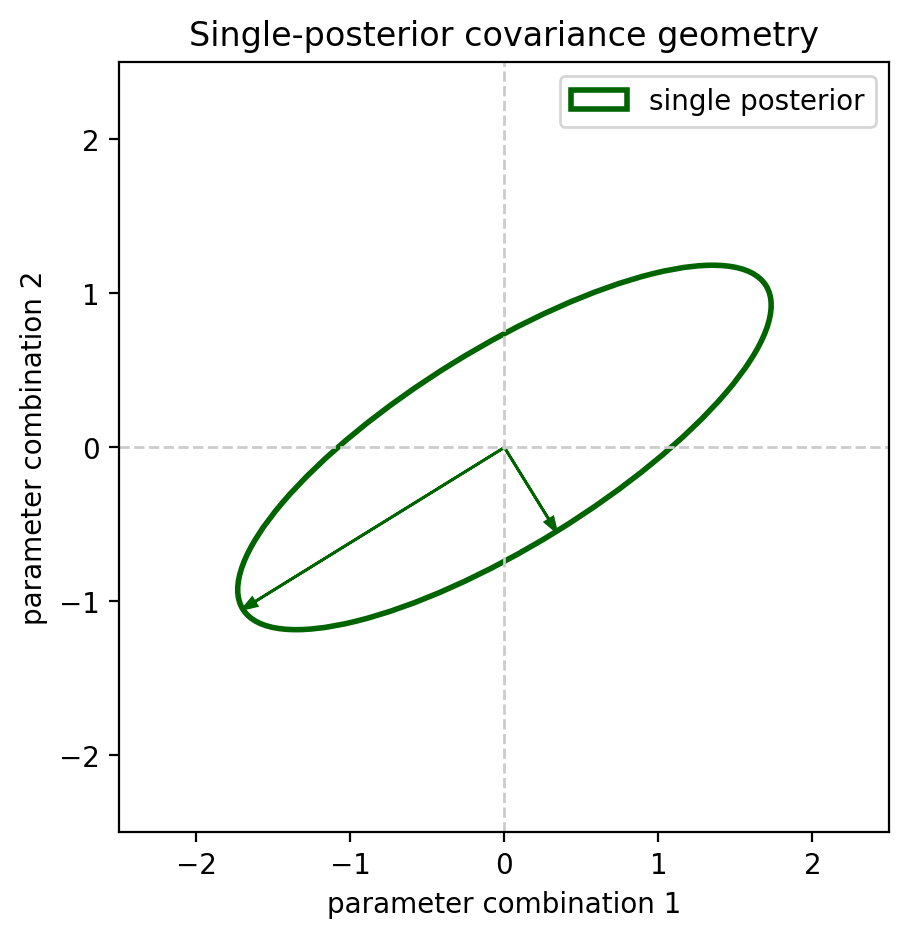

In [2]:
def draw_covariance_ellipse(ax, cov, color, label, center=(0.0, 0.0), nsigma=1.0, lw=2.0, alpha=1.0):
    evals, evecs = np.linalg.eigh(cov)
    order = np.argsort(evals)[::-1]
    evals = evals[order]
    evecs = evecs[:, order]

    angle = np.degrees(np.arctan2(evecs[1, 0], evecs[0, 0]))
    width = 2 * nsigma * np.sqrt(evals[0])
    height = 2 * nsigma * np.sqrt(evals[1])

    ell = Ellipse(xy=center, width=width, height=height, angle=angle,
                  fill=False, edgecolor=color, linewidth=lw, alpha=alpha, label=label)
    ax.add_patch(ell)

    for i in range(2):
        vec = evecs[:, i] * np.sqrt(evals[i])
        ax.arrow(center[0], center[1], vec[0], vec[1], color=color,
                 width=0.0, head_width=0.06, length_includes_head=True, alpha=alpha)

    ax.set_aspect("equal")


C_single = np.array([[3.0, 1.6], [1.6, 1.4]])

fig, ax = plt.subplots()
draw_covariance_ellipse(ax, C_single, color="darkgreen", label="single posterior")
ax.axhline(0, color="0.8", ls="--", lw=1)
ax.axvline(0, color="0.8", ls="--", lw=1)
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_xlabel("parameter combination 1")
ax.set_ylabel("parameter combination 2")
ax.set_title("Single-posterior covariance geometry")
ax.legend()
plt.show()

### 3.2 How do we quantify shifts between two posterior means?

Before asking how the *shape* of the posteriors changes, it is useful to ask whether their centers move.

If the posterior means are $\mu_A$ and $\mu_B$, we define

$\Delta \mu \equiv \mu_B - \mu_A.$

This vector tells us the direction of the mean displacement in parameter space, but by itself it does not tell us whether the shift is large or small relative to the posterior widths. To make that comparison meaningful, the package measures the displacement in covariance-weighted units.

Three geometric shift metrics are used.

**1) Shift of `B` from `A` in the units of `A`**

$S_{B\mid A} \equiv \sqrt{\Delta\mu^T \, C_A^{-1} \, \Delta\mu}$

This answers the question:

> how far is the center of `B`, measured using the internal scale of `A`?

**2) Shift of `A` from `B` in the units of `B`**

$S_{A\mid B} \equiv \sqrt{\Delta\mu^T \, C_B^{-1} \, \Delta\mu}$

This is the same geometric displacement, but measured using the scale of `B` instead.

**Symmetric combined-covariance distance**

$S_{AB} \equiv \sqrt{\Delta\mu^T \, (C_A + C_B)^{-1} \, \Delta\mu}$

This is a symmetric measure of geometric separation between the two centers.

The interpretation is straightforward:

- large $S_{B|A}$ means that `B` is far from `A` relative to the width of `A`,
- large $S_{A|B}$ means that `A` is far from `B` relative to the width of `B`,
- large $S_{AB}$ means that the two centers are geometrically well separated in combined covariance units.

These metrics are useful because they separate two different questions:

> Are the posterior centers shifted? Even if they are shifted, is that shift large compared with the natural widths of the posteriors?

These are Mahalanobis distances, not Gaussian-sigma tension significances. Even for independent Gaussian estimates, n-dimensional radii require an appropriate reference distribution. Shared observations additionally require cross-covariances to calibrate a difference-of-estimates test; this package does not estimate them.


### 3.3 How do we quantify rotation between two posteriors?

Angles require a metric: changing from $H_0$ to $h=H_0/100$ changes the numerical
aspect ratio of parameter space. Version 1.0.0 therefore compares axes in a common
reference-sigma coordinate system by default:

$$D_A=\mathrm{diag}(\sigma_{A,1},\ldots,\sigma_{A,n}),\qquad z=D_A^{-1}(x-\mu_A).$$
$$\widehat C_A=D_A^{-1}C_AD_A^{-1},\qquad \widehat C_B=D_A^{-1}C_BD_A^{-1}.$$

Both matrices use **A's** scales. A has unit marginal variances but retains its
correlations; this is not full whitening. Let $w_i^{(A)}$ and $w_j^{(B)}$ be the
orthonormal PCA eigenvectors of these standardized matrices. We report

$$O_{ij}=|(w_i^{(A)})^T w_j^{(B)}|.$$

- One means aligned axes; zero means orthogonal axes.
- These overlaps are invariant under common changes of parameter units, but
  still depend on the selected parameters and the reference metric.
- The indices refer to **standardized** PCA modes, distinct from the raw PCA
  modes printed in report sections A and B.
- Eigenvector signs and permutations are not physical rotations. Near-degenerate
  eigenvalues make individual axes unstable. A ratio of adjacent eigenvalues at
  most 1.1 triggers a heuristic note with `interpretation=True`.
- For an isolated eigenvalue cluster, principal angles between its subspaces are
  more useful; comparing the entire n-dimensional space always gives zero angles.

`rotation_basis="original"` retains the original-coordinate diagnostic. The
illustration below is deliberately preserved in **original coordinates**: its
ellipse angles and overlap explain this optional raw metric. The standardized,
unit-invariant diagnostic is tested separately in Validation, Case 5.


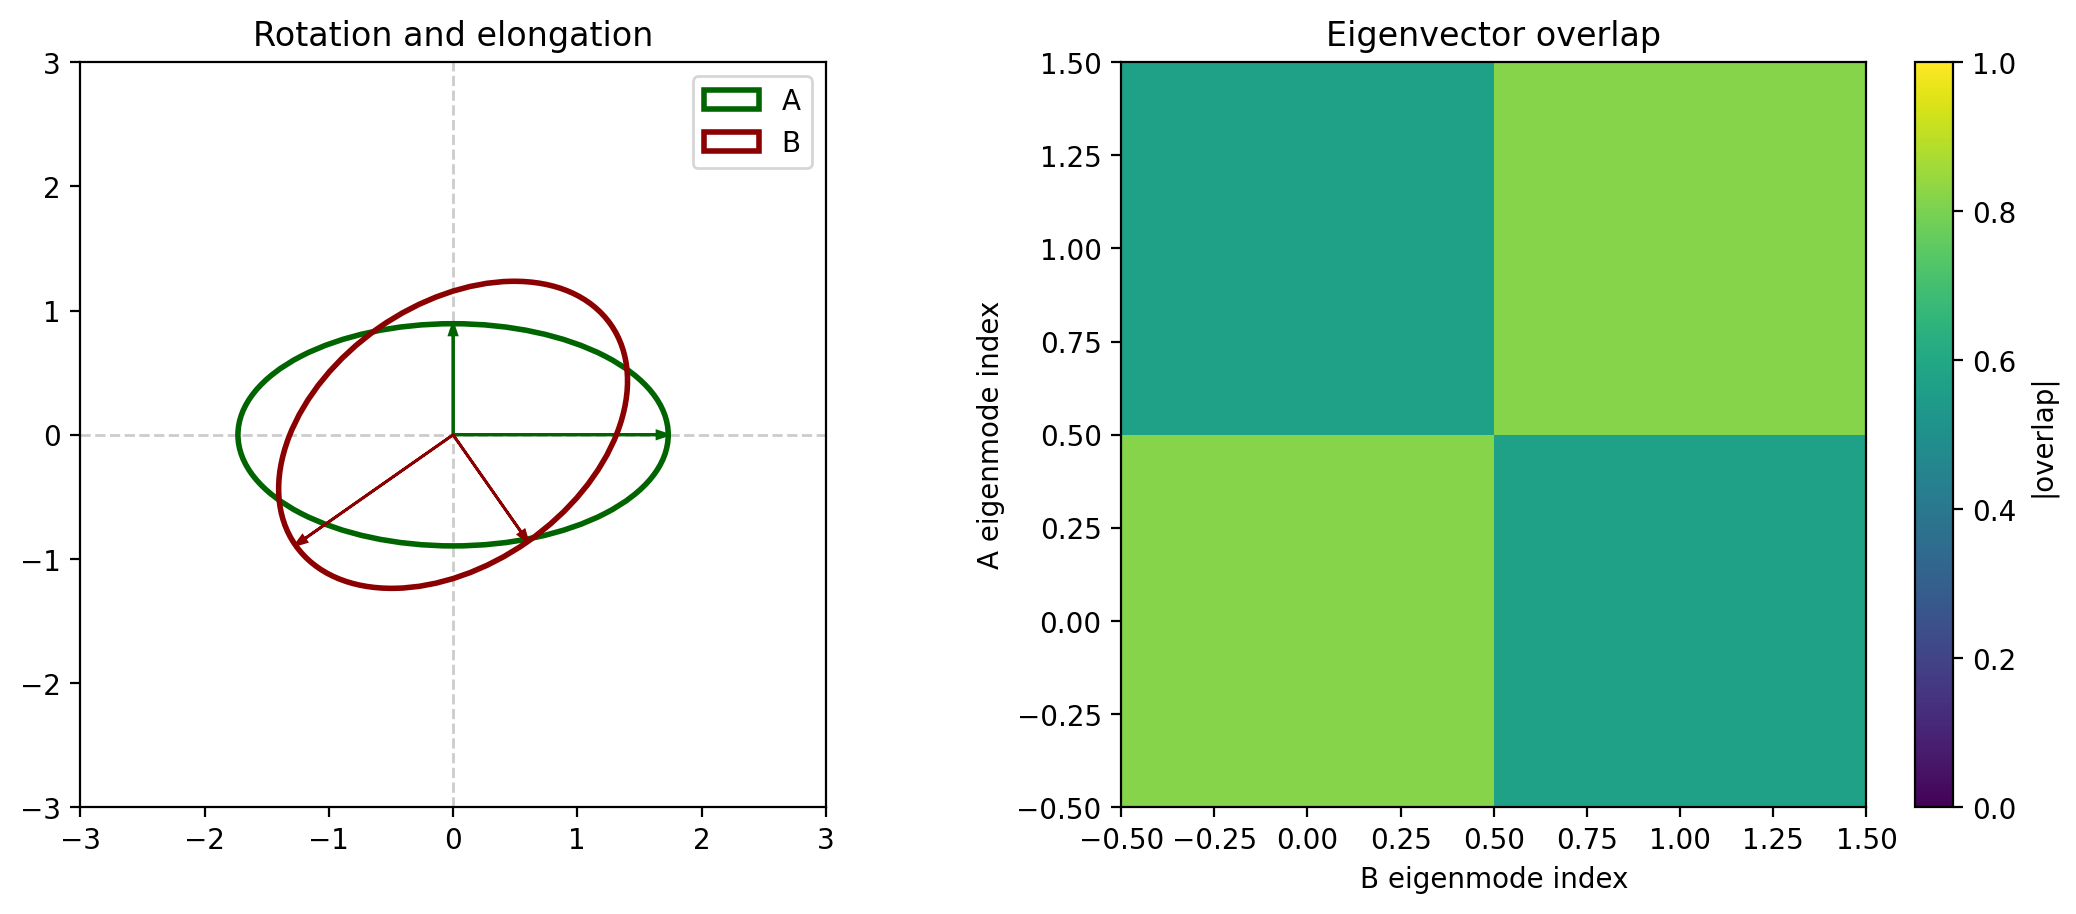

In [3]:
theta = np.deg2rad(35)
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])

C_rot_A = np.array([[3.0, 0.0], [0.0, 0.8]])
C_rot_B = R @ np.array([[2.4, 0.0], [0.0, 1.1]]) @ R.T

evals_A2, evecs_A2 = np.linalg.eigh(C_rot_A)
evals_B2, evecs_B2 = np.linalg.eigh(C_rot_B)
overlap = np.abs(evecs_A2.T @ evecs_B2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

draw_covariance_ellipse(axes[0], C_rot_A, color="darkgreen", label="A")
draw_covariance_ellipse(axes[0], C_rot_B, color="darkred", label="B")
axes[0].set_xlim(-3, 3)
axes[0].set_ylim(-3, 3)
axes[0].set_title("Rotation and elongation")
axes[0].axhline(0, color="0.8", ls="--", lw=1, zorder=0)
axes[0].axvline(0, color="0.8", ls="--", lw=1, zorder=0)
axes[0].legend()

im = axes[1].imshow(overlap, origin="lower", cmap="viridis", vmin=0, vmax=1)
axes[1].set_xlabel("B eigenmode index")
axes[1].set_ylabel("A eigenmode index")
axes[1].set_title("Eigenvector overlap")
fig.colorbar(im, ax=axes[1], label="|overlap|")

plt.tight_layout()
plt.show()

### 3.4 How do we quantify elongation or compression?

Rotation is only part of the story. Even if two posteriors point in almost the same directions, they may still differ strongly in how stretched they are along those directions.

A naive comparison of the eigenvalues of `A` and `B` is often not enough, because the axes themselves may rotate. What we really want is a direction-by-direction comparison in the basis that is most natural for the *relative* change between the two posteriors.


To compare `B` against a reference posterior `A`, we first remove the geometry of `A` itself. 

This is done by **whitening** with $C_A^{-1/2}$ and constructing

$C = C_A^{-1/2} \,  C_B \, C_A^{-1/2}.$

This step has a clear geometric meaning. In the whitened coordinates:

- the reference posterior `A` becomes a unit sphere,
- the alternative posterior `B` becomes the deformed object we want to study.

The effect of whitening is schematically illustrated in the figure below:


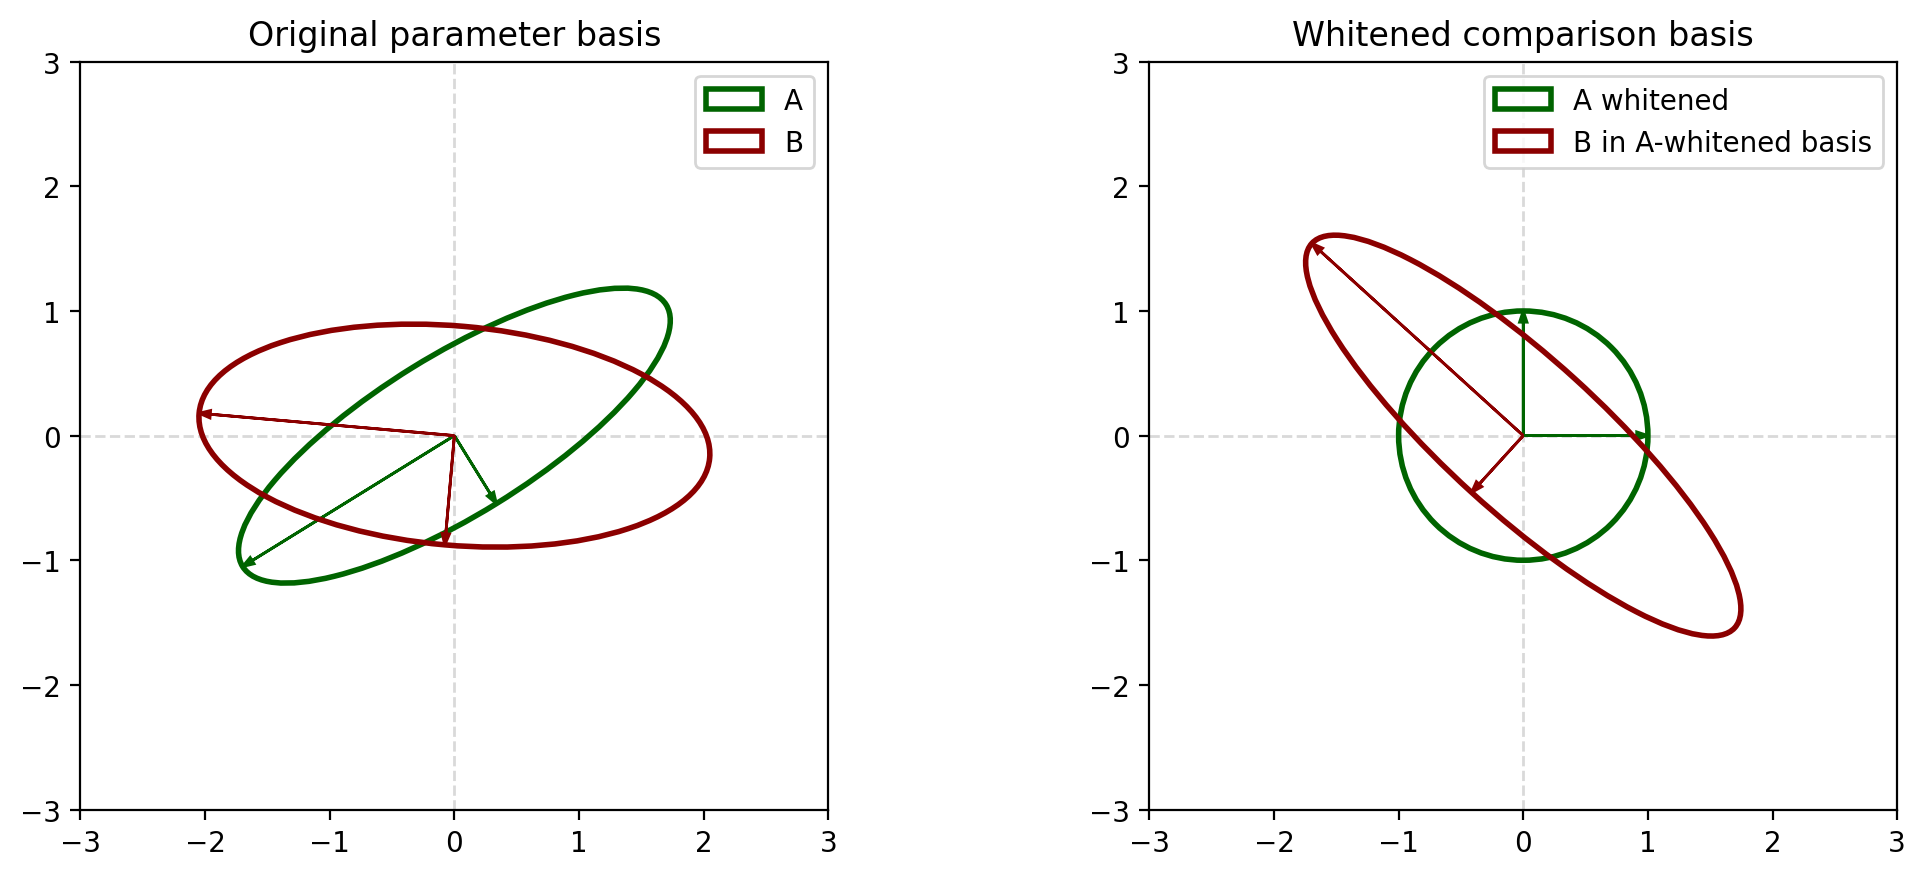

In [4]:
C_A = np.array([[3.0, 1.6], [1.6, 1.4]])
C_B = np.array([[4.2, -0.3], [-0.3, 0.8]])

evals_A, evecs_A = np.linalg.eigh(C_A)
inv_sqrt_A = (evecs_A * (1.0 / np.sqrt(evals_A))) @ evecs_A.T
C_whitened = inv_sqrt_A @ C_B @ inv_sqrt_A
C_whitened = 0.5 * (C_whitened + C_whitened.T)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

draw_covariance_ellipse(axes[0], C_A, color="darkgreen", label="A")
draw_covariance_ellipse(axes[0], C_B, color="darkred", label="B")
axes[0].set_xlim(-3, 3)
axes[0].set_ylim(-3, 3)
axes[0].set_title("Original parameter basis")
axes[0].legend()

draw_covariance_ellipse(axes[1], np.eye(2), color="darkgreen", label="A whitened")
draw_covariance_ellipse(axes[1], C_whitened, color="darkred", label="B in A-whitened basis")
axes[1].set_xlim(-3, 3)
axes[1].set_ylim(-3, 3)
axes[1].set_title("Whitened comparison basis")
axes[1].legend()

for ax in axes:
    ax.axhline(0, color="0.85", lw=1, ls="--", zorder=0)
    ax.axvline(0, color="0.85", lw=1, ls="--", zorder=0)

plt.tight_layout()
plt.show()

It basically answers the question:

> what does `B` look like once the internal scale and orientation of `A` have been factored out?

This is the central object of the package, because it isolates the *relative* geometry of `B` with respect to `A`.

### 3.5 What do the eigenvalues of the comparison matrix mean?

After whitening, we diagonalize the comparison matrix:

$C = U \, D \, U^T.$

The eigenvalues $\rho_i$ in `D` are the generalized variance ratios. They are the multidimensional analogue of the 1D ratio $\sigma_B^2 / \sigma_A^2$.

Their interpretation is therefore:

- $\rho_i > 1$: along that mode, `B` is broader than `A`,
- $\rho_i < 1$: along that mode, `B` is tighter than `A`,
- $\rho_i = 1$: that mode is preserved.

Therefore once `A` has been whitened to the identity, the eigenvalues of the transformed matrix tell us exactly how much `B` is stretched or compressed along the special directions of the comparison. This is the analogue of the 1D case


### 3.6 How do we separate isotropic and anisotropic deformation?

The eigenvalues of the comparison matrix `C` tell us how the variance changes mode by mode, but it is also useful to summarize the deformation more globally.

A particularly clean decomposition is to separate:

- an **overall isotropic rescaling**,
- a **residual anisotropic distortion of shape**.

If the change from `A` to `B` were the same **isotropic** (i.e., in every direction), then after whitening we would have

$C = \alpha I$,

for some constant $\alpha$. In that idealized case:

- `A` would become a unit sphere,
- `B` would remain a sphere, but with a larger or smaller radius.

So the most natural **isotropic scale factor** is the geometric mean of the generalized eigenvalues:

$\alpha = (\det C)^{1/N} = \exp\!\left[\frac{1}{N}\sum_i \log \rho_i\right].$

Its interpretation is simple:

- $\alpha > 1$: `B` is broader than `A` on average,
- $\alpha < 1$: `B` is tighter than `A` on average,
- $\alpha = 1$: there is no average global rescaling.

Once this isotropic part is factored out, the remaining question is whether the deformation is still direction-dependent. A convenient **anisotropy measure** is the dispersion of the log-eigenvalues around their mean:

$A_{\mathrm{aniso}} = \sqrt{\frac{1}{N}\sum_i \left(\log \rho_i - \overline{\log \rho}\right)^2}.$

This quantity has three useful properties:

- $A_{\mathrm{aniso}}=0$ if all generalized eigenvalues are equal,
- it is insensitive to the global isotropic factor $\alpha$,
- it isolates pure shape distortion.

So in the code:

- $\alpha$ measures the average isotropic widening or tightening,
- $A_{\mathrm{aniso}}$ measures how far the deformation is from a simple uniform rescaling.

This is geometrically useful because it separates the question

> does `B` differ from `A` mostly by an overall change of size?

from the question

> does `B` distort the posterior shape differently in different directions?




All logarithms are natural. Alpha is a variance scale; sqrt(alpha) is a linear scale. At fixed ellipsoidal radius, the volume ratio is alpha^(n/2). A rotation of an anisotropic ellipsoid can also generate nonzero A_aniso, so rotation and relative deformation do not identify disjoint physical effects.


### 3.7 What is a generalized mode?

If $C=U\,\mathrm{diag}(\rho_i)U^T$, the projection coefficients are
$$V=C_A^{-1/2}U,\qquad m=V^T(x-\mu_A).$$
They satisfy
$$V^T C_A V=I,\qquad V^T C_B V=\mathrm{diag}(\rho_i).$$

The same coefficients and common origin are used for both chains. Thus A has
unit covariance while B retains its mean shift and its relative widths. These
identities are exact for the input covariances. Empirical weighted variances agree
when the projected chains reproduce those covariances.

The default `normalization="reference"` implements this convention.
`normalization="euclidean"` divides each column by its Euclidean norm; it keeps
the same variance ratios but no longer makes A unit covariance. Reported direction
coefficients use this readable Euclidean normalization and depend on parameter units.

`center="separate"` subtracts each chain's own weighted mean, displaying shapes
without mean shifts. `center="none"` uses the original origin. Histograms, KDEs,
means and variances must retain sample weights. GetDist derived-parameter helpers
preserve them automatically.

Strictly, columns of V are **linear functionals (covectors)**, not displacement
axes of the original ellipsoid. Moving one mode coordinate while fixing all others
corresponds to a column of $V^{-T}=C_A^{1/2}U$. Generalized coefficients need not be
Euclidean-orthogonal in the original coordinates. Their projected covariances are
diagonal, but non-Gaussian distributions may retain nonlinear dependence.

The numerical solver uses dimensionless scaling and Cholesky solves; an orthogonal
polar factor recovers the displayed symmetric-whitening C. Residuals check both
covariance identities and the generalized equation. Singular inputs are rejected,
not assigned artificial finite logarithmic deformation metrics.


### 3.8 What is the difference between the modes of `A`, `B`, and `C`?

It is useful to keep the three notions sharply separated.

**Modes of `A`**
- obtained from the eigen-decomposition of `C_A`,
- describe the internal geometry of the reference posterior,
- tell us which directions are naturally narrow or broad in `A`.

**Modes of `B`**
- obtained from the eigen-decomposition of `C_B`,
- describe the internal geometry of the alternative posterior,
- tell us which directions are naturally narrow or broad in `B`.

**Modes of `C = C_A^{-1/2} C_B C_A^{-1/2}`**
- obtained from the generalized comparison problem,
- do not describe a single posterior in isolation,
- describe instead the directions that are most informative for the *difference* between `A` and `B`.

This is why the package treats the comparison modes as the main output, while the separate PCA modes of `A` and `B` play a supporting interpretive role.



Rotation statements in the default report refer to common reference-sigma coordinates. Raw A/B PCA axes remain available separately. These are covariance diagnostics; they do not establish equality of full non-Gaussian posteriors or calibrate statistical tension.


### 3.9 How is this used in practice?

The package extracts five complementary pieces of information.

**1) Shift diagnostics**
- from covariance-weighted distances between the posterior means.

**2) Rotation diagnostics**
- from the overlap between the eigenvector bases of `A` and `B`.

**3) Elongation or compression diagnostics**
- from the generalized eigenvalues `\rho_i`.

**4) Global deformation diagnostics**
- from `alpha` and `A_aniso`, which separate overall rescaling from anisotropic shape distortion.

**5) Mode interpretation**
- from the generalized eigenvectors mapped back to the original parameter basis.

In the IDE example, this means:

- use the PCA of `A` and `B` to understand the internal geometry of the two posteriors,
- use shift metrics to quantify whether the posterior centers move,
- use overlaps to quantify whether compressed CMB information rotates the main degeneracy directions,
- use the generalized modes to identify the specific parameter combinations whose variances change the most when full Planck is replaced by geometric CMB compression.

The contour plots in the generalized-mode basis are especially useful because they show both posteriors in the coordinate system that is optimal for reading their difference.


Rotation statements in the default report refer to common reference-sigma coordinates. Raw A/B PCA axes remain available separately. These are covariance diagnostics; they do not establish equality of full non-Gaussian posteriors or calibrate statistical tension.


### 3.10 Why does this framework answer the original question?

The original question was not simply whether two posterior constraints differ, but *how* they differ geometrically.

The framework above answers that systematically:

- the PCA of `A` tells us the geometry of the reference posterior,
- the PCA of `B` tells us the geometry of the alternative posterior,
- the shift metrics tell us whether the posterior centers move and how large that displacement is in posterior units,
- the overlap matrix tells us how much the principal directions rotate,
- the generalized eigenvalues tell us how much each relevant direction broadens or tightens,
- the `alpha` / `A_aniso` decomposition tells us whether the change is mostly isotropic or strongly anisotropic,
- the generalized modes tell us which combinations of physical parameters define those directions.

So the full comparison is not reduced to a single scalar summary. It is decomposed into:

- orientation,
- relative stretching,
- and physically interpretable parameter combinations.

That is the basic theoretical idea behind `posterior-eigenmodes`.


Rotation statements in the default report refer to common reference-sigma coordinates. Raw A/B PCA axes remain available separately. These are covariance diagnostics; they do not establish equality of full non-Gaussian posteriors or calibrate statistical tension.
